### Set up all data + libraries + initialization

In [1]:
# Mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [131]:
# Importing libraries
import os
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
import time
import csv
from tqdm import tqdm

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from IPython.display import Image, display
from PIL import Image
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [58]:
# Make dir's for all the data/models
base_dir = "/content/drive/My Drive/gan2"
data_dir = os.path.join(base_dir, "data")

train_128_dir = os.path.join(data_dir, "train_128")
test_128_dir = os.path.join(data_dir, "test_128")

train_32_dir = os.path.join(data_dir, "train_32")
test_32_dir = os.path.join(data_dir, "test_32")

model_dir = os.path.join(base_dir, "models")
modelA_dir = os.path.join(model_dir, "modelA")
modelB_dir = os.path.join(model_dir, "modelB")
os.makedirs(model_dir, exist_ok=True)

In [59]:
# list the number of images in each of the directories
print("Number of images in train_128:", len(os.listdir(train_128_dir)))
print("Number of images in test_128:", len(os.listdir(test_128_dir)))
print("Number of images in train_32:", len(os.listdir(train_32_dir)))
print("Number of images in test_32:", len(os.listdir(test_32_dir)))

Number of images in train_128: 16800
Number of images in test_128: 7200
Number of images in train_32: 16800
Number of images in test_32: 7200


### Create the binary classifier (A) (Essentially the same as the CNN we made earlier)

##### Define the dataframe

In [60]:
def make_dataframe_numeric(img_dir):
    files = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))
    labels = [1 if os.path.basename(f).startswith("dog") else 0 for f in files]
    df = pd.DataFrame({"filename": files, "label": labels})
    return df

train128_df = make_dataframe_numeric(train_128_dir)
test128_df  = make_dataframe_numeric(test_128_dir)
train32_df  = make_dataframe_numeric(train_32_dir)
test32_df   = make_dataframe_numeric(test_32_dir)

print(train128_df.head())
print(f"Train images: {len(train128_df)} | Test images: {len(test128_df)}")

                                            filename  label
0  /content/drive/My Drive/gan2/data/train_128/ca...      0
1  /content/drive/My Drive/gan2/data/train_128/ca...      0
2  /content/drive/My Drive/gan2/data/train_128/ca...      0
3  /content/drive/My Drive/gan2/data/train_128/ca...      0
4  /content/drive/My Drive/gan2/data/train_128/ca...      0
Train images: 16800 | Test images: 7200


##### Define Augmentations

In [65]:
# Define desaturation
def desaturation(img, lower=0.45, upper=0.95):
  img = tf.cast(img, tf.float32)
  img_grey = tf.image.rgb_to_grayscale(img)
  img_grey = tf.tile(img_grey, [1, 1, 3])
  alpha = tf.random.uniform([], lower, upper)
  img = img_grey * alpha + img * (1 - alpha)
  return img

# Define img_augment
def img_augment(img):
  img = tf.image.random_brightness(img, 0.5)
  img = tf.image.random_flip_left_right(img)
  # img = tf.image.random_hue(img, 0.2)
  # img = tf.image.central_crop(img, 0.7)
  img = desaturation(img, lower=0.4, upper=0.9)
  return img

# Define img_load
def img_load(filename):
  img = tf.io.read_file(filename)
  img = tf.io.decode_jpeg(img, channels=3)
  return img

# Define img_norm (Scale from [-1, 1])
def img_norm(img):
  img = tf.cast(img, tf.float32)
  img = img / 127.5 - 1.0
  return img

# define imageLoader
def imageLoader(filename, label, augment=True):
  img = img_load(filename)
  if augment:
    img = img_augment(img)
  img = img_norm(img)
  # label is already numeric (0 or 1)
  label = tf.cast(label, tf.int32)
  return img, label


##### Apply Augmentations

In [66]:
# Apply augmentations
train_128_ds = tf.data.Dataset.from_tensor_slices((train128_df["filename"], train128_df["label"]))
train_128_ds = train_128_ds.map(lambda x, y: imageLoader(x, y, augment=True),
                        num_parallel_calls=tf.data.AUTOTUNE)
train_128_ds = train_128_ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

test_128_ds = tf.data.Dataset.from_tensor_slices((test128_df["filename"], test128_df["label"]))
test_128_ds = test_128_ds.map(lambda x, y: imageLoader(x, y, augment=False),
                      num_parallel_calls=tf.data.AUTOTUNE)
test_128_ds = test_128_ds.batch(32).prefetch(tf.data.AUTOTUNE)


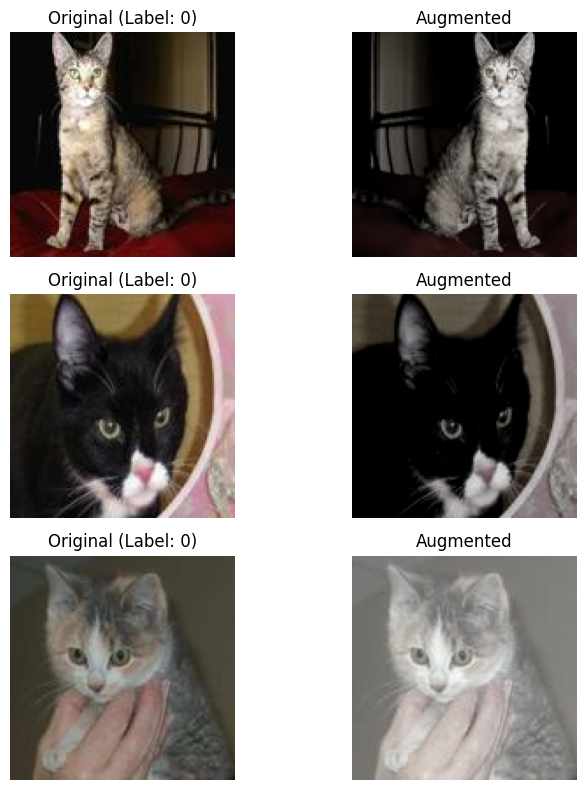

In [67]:
import matplotlib.pyplot as plt

# Pull three samples manually (not using .take yet)
filenames = train128_df["filename"].iloc[:3]
labels = train128_df["label"].iloc[:3]

plt.figure(figsize=(8, 8))

for i in range(3):
    # Load original
    img_orig, _ = imageLoader(filenames[i], labels[i], augment=False)
    img_orig = (img_orig.numpy() + 1) / 2

    # Load augmented version of the *same* image
    img_aug, _ = imageLoader(filenames[i], labels[i], augment=True)
    img_aug = (img_aug.numpy() + 1) / 2

    # Row i: original (left), augmented (right)
    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(img_orig)
    plt.title(f"Original (Label: {labels[i]})")
    plt.axis("off")

    plt.subplot(3, 2, 2*i + 2)
    plt.imshow(img_aug)
    plt.title("Augmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

##### Define the model and train

In [71]:
# Define model
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights="imagenet")

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), loss="binary_crossentropy", metrics=["accuracy"])

# Used for Internal Tensorboard
csv_logger = CSVLogger("modelA.csv", append=False)

# Train model
history = model.fit(train_128_ds, validation_data=test_128_ds, epochs=25, callbacks=[csv_logger])

Epoch 1/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 40s 60ms/step - accuracy: 0.8776 - loss: 0.3352 - val_accuracy: 0.5131 - val_loss: 1.0489
Epoch 2/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.7196 - loss: 0.6001 - val_accuracy: 0.6961 - val_loss: 0.6317
Epoch 3/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.8233 - loss: 0.4123 - val_accuracy: 0.7919 - val_loss: 0.4877
Epoch 4/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8577 - loss: 0.3349 - val_accuracy: 0.8313 - val_loss: 0.4072
Epoch 5/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.8830 - loss: 0.2810 - val_accuracy: 0.8515 - val_loss: 0.3683
Epoch 6/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.8902 - loss: 0.2646 - val_accuracy: 0.8650 - val_loss: 0.3396
Epoch 7/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.8993 - loss: 0.2473 - val_accuracy: 0.8721 - val_loss: 0.3220
Epoch 8/25
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8999 - loss: 0.2436 - 

In [72]:
# Save model weights
model.save(os.path.join(modelA_dir, "modelA.keras"))

Saved plots:
/content/drive/My Drive/gan2/models/modelA/modelA_Acc_plot.png True
/content/drive/My Drive/gan2/models/modelA/modelA_Loss_plot.png True


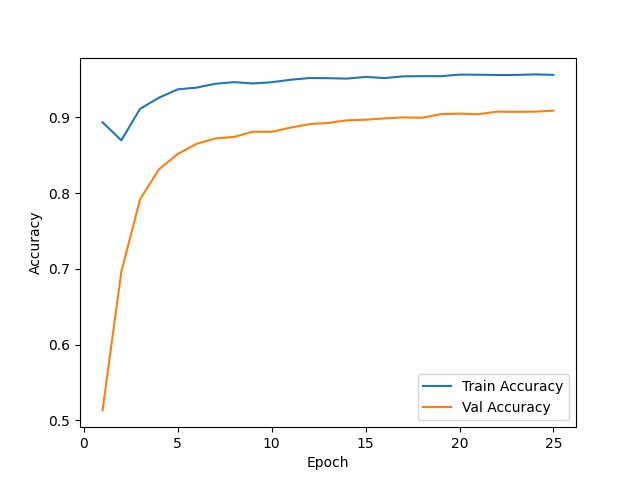

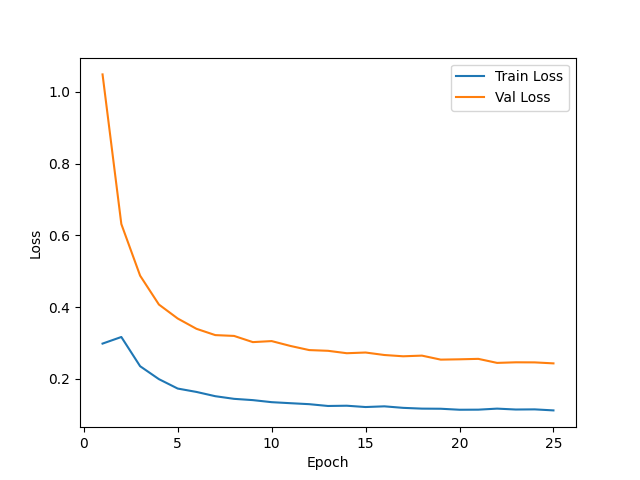

In [74]:
# Save CSV (add epoch column)
hist_df = pd.DataFrame(history.history)
hist_df["epoch"] = range(1, len(hist_df) + 1)
csv_path = os.path.join(modelA_dir, "modelA.csv")
hist_df.to_csv(csv_path, index=False)

# Read CSV
log_128 = pd.read_csv(csv_path)

# Accuracy plot
acc_path = os.path.join(modelA_dir, "modelA_Acc_plot.png")
plt.figure()
plt.plot(log_128["epoch"], log_128["accuracy"], label="Train Accuracy")
if "val_accuracy" in log_128.columns:
    plt.plot(log_128["epoch"], log_128["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(acc_path)
plt.close()

# Loss plot
loss_path = os.path.join(modelA_dir, "modelA_Loss_plot.png")
plt.figure()
plt.plot(log_128["epoch"], log_128["loss"], label="Train Loss")
if "val_loss" in log_128.columns:
    plt.plot(log_128["epoch"], log_128["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(loss_path)
plt.close()

# Verify the files exist
print("Saved plots:")
print(acc_path, os.path.exists(acc_path))
print(loss_path, os.path.exists(loss_path))

from IPython.display import Image, display
display(Image(filename=acc_path))
display(Image(filename=loss_path))


##### Determine Scores

In [85]:
# Collect predictions
y_true = []
y_pred = []

for imgs, labels in test_128_ds:
    preds = model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Find best threshold using ROC
fpr, tpr, thresholds = roc_curve(y_true, y_pred)
best_thresh = thresholds[np.argmax(tpr - fpr)]
print(f"Best threshold: {best_thresh:.4f}")

# Apply threshold and compute metrics
y_class = (y_pred > best_thresh).astype(int)

acc = accuracy_score(y_true, y_class)
f1  = f1_score(y_true, y_class)
auc = roc_auc_score(y_true, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")


Best threshold: 0.9983
Accuracy: 0.8493
F1 Score: 0.8471
AUC: 0.9240


### Train SRGAN to generate 128res from 32res images

In [106]:
# paths
train_lr_dir = train_32_dir
train_hr_dir = train_128_dir
test_lr_dir  = test_32_dir
test_hr_dir  = test_128_dir


In [107]:
def load_image_pair(lr_path, hr_path):
    # Load and normalize low-res image
    lr = tf.io.read_file(lr_path)
    lr = tf.io.decode_jpeg(lr, channels=3)
    lr = tf.cast(lr, tf.float32) / 127.5 - 1.0  # normalize to [-1, 1]

    # Load and normalize high-res image
    hr = tf.io.read_file(hr_path)
    hr = tf.io.decode_jpeg(hr, channels=3)
    hr = tf.cast(hr, tf.float32) / 127.5 - 1.0
    return lr, hr

def make_paired_dataset(lr_dir, hr_dir, batch_size=8):
    # Match LR and HR file paths
    lr_files = sorted(glob.glob(os.path.join(lr_dir, "*.jpg")))
    hr_files = sorted(glob.glob(os.path.join(hr_dir, "*.jpg")))

    # Create paired dataset
    ds = tf.data.Dataset.from_tensor_slices((lr_files, hr_files))
    ds = ds.map(lambda x, y: load_image_pair(x, y),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Create datasets
train_sr_ds = make_paired_dataset(train_lr_dir, train_hr_dir)
test_sr_ds  = make_paired_dataset(test_lr_dir, test_hr_dir)

In [108]:
def build_generator():
    inputs = layers.Input(shape=(32, 32, 3))

    # Initial conv
    x = layers.Conv2D(64, 9, padding='same')(inputs)
    x = layers.PReLU(shared_axes=[1, 2])(x)
    skip = x

    # Lighter residual block (no BatchNorm)
    def res_block(x_in):
        y = layers.Conv2D(64, 3, padding='same')(x_in)
        y = layers.PReLU(shared_axes=[1, 2])(y)
        y = layers.Conv2D(64, 3, padding='same')(y)
        # scale residual by 0.1 for stability
        y = layers.Lambda(lambda z: z * 0.1)(y)
        return layers.add([x_in, y])

    for _ in range(8):        # reduced from 16 → 8
        x = res_block(x)

    # Add skip connection
    x = layers.add([x, skip])

    # Faster bilinear upsampling blocks
    for _ in range(2):        # ×4 upscale total
        x = layers.UpSampling2D(size=2, interpolation='bilinear')(x)
        x = layers.Conv2D(64, 3, padding='same')(x)
        x = layers.PReLU(shared_axes=[1, 2])(x)

    # Output layer (tanh for [-1,1])
    x = layers.Conv2D(3, 9, padding='same', activation='tanh')(x)

    return models.Model(inputs, x, name="GeneratorFast")

generator = build_generator()
generator.summary()


Model: "GeneratorFast"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 32, 32,    │     15,616 │ input_layer_15[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_19 (PReLU)  │ (None, 32, 32,    │         64 │ conv2d_45[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 32, 32,    │     36,928 │ p_re_lu_19[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_20 (PReLU)  │ (None, 32, 32,    │         64 │ conv2d_46[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 32, 32,    │     36,928 │ p_re_lu_20[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32, 32,    │          0 │ conv2d_47[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, 32, 32,    │          0 │ p_re_lu_19[0][0], │
│                     │ 64)               │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 32, 32,    │     36,928 │ add_17[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_21 (PReLU)  │ (None, 32, 32,    │         64 │ conv2d_48[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 32, 32,    │     36,928 │ p_re_lu_21[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 32, 32,    │          0 │ conv2d_49[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 32, 32,    │          0 │ add_17[0][0],     │
│                     │ 64)               │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 32, 32,    │     36,928 │ add_18[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ p_re_lu_22 (PReLU)  │ (None, 32, 32,    │         64 │ conv2d_50[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 32, 32,    │     36,928 │ p_re_lu_22[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 32, 32,    │          0 │ conv2d_51[0][0] 

 Total params: 696,579 (2.66 MB)

 Trainable params: 696,579 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

In [113]:
def build_discriminator_ultra():
    def block(x, f, s=1, bn=True):
        x = layers.Conv2D(f, 3, strides=s, padding="same")(x)
        if bn:
            x = layers.BatchNormalization()(x)
        return layers.LeakyReLU(0.2)(x)

    inp = layers.Input((128, 128, 3))

    # Fewer convs, early stride-2 downsamples
    x = block(inp, 64, bn=False)
    x = block(x, 128, s=2)
    x = block(x, 256, s=2)
    x = block(x, 512, s=2)

    # Replace dense stack with global pooling head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation="leaky_relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inp, out, name="DiscriminatorUltra")

discriminator = build_discriminator_ultra()
discriminator.summary()

Model: "DiscriminatorUltra"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,587,457 (6.06 MB)

 Trainable params: 1,585,665 (6.05 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [114]:
# Loss functions
bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)  # faster, numerically stable
mse = tf.keras.losses.MeanSquaredError()

# Optimizers (tuned for faster convergence)
g_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)


In [115]:
@tf.function
def train_step(lr_imgs, hr_imgs):
    batch_size = tf.shape(lr_imgs)[0]
    valid = tf.ones((batch_size, 1))
    fake  = tf.zeros((batch_size, 1))

    with tf.GradientTape(persistent=True) as tape:
        # Generate high-res images
        gen_hr = generator(lr_imgs, training=True)

        # Discriminator predictions
        real_out = discriminator(hr_imgs, training=True)
        fake_out = discriminator(gen_hr, training=True)

        # Generator losses
        content_loss = mse(hr_imgs, gen_hr)
        adv_loss = bce(valid, fake_out)
        g_loss = content_loss + 1e-3 * adv_loss   # weighted combo

        # Discriminator loss
        d_loss = 0.5 * (
            bce(valid, real_out) +
            bce(fake,  fake_out)
        )

    # Compute gradients once per network
    g_grads = tape.gradient(g_loss, generator.trainable_variables)
    d_grads = tape.gradient(d_loss, discriminator.trainable_variables)

    # Apply gradients
    g_optimizer.apply_gradients(zip(g_grads, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))

    del tape  # free memory early

    return g_loss, d_loss


In [119]:
epochs = 150
save_interval = 15

# Create SRGAN folder inside your existing model_dir
srgan_dir = os.path.join(model_dir, "modelSRGAN")
os.makedirs(srgan_dir, exist_ok=True)

csv_path = os.path.join(srgan_dir, "srgan_losses.csv")

# Initialize CSV logger if it doesn’t exist
if not os.path.exists(csv_path):
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "g_loss", "d_loss", "time_sec"])

for epoch in range(1, epochs + 1):
    start = time.time()
    g_losses, d_losses = [], []

    # Training loop
    for lr_batch, hr_batch in train_sr_ds:
        g_loss, d_loss = train_step(lr_batch, hr_batch)
        g_losses.append(float(g_loss))
        d_losses.append(float(d_loss))

    # Average losses per epoch
    g_mean = tf.reduce_mean(g_losses).numpy()
    d_mean = tf.reduce_mean(d_losses).numpy()
    epoch_time = time.time() - start

    print(f"Epoch [{epoch}/{epochs}]  "
          f"G_loss={g_mean:.4f}  D_loss={d_mean:.4f}  "
          f"Time={epoch_time:.2f}s")

    # Save losses to CSV
    with open(csv_path, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, g_mean, d_mean, epoch_time])

    # Save example images and weights every 5 epochs
    if epoch % save_interval == 0:
        for lr_ex, hr_ex in test_sr_ds.take(1):
            fake_hr = generator(lr_ex, training=False)
            fake_hr = (fake_hr + 1) / 2.0
            hr_ex = (hr_ex + 1) / 2.0
            lr_ex = (lr_ex + 1) / 2.0

            fig, axs = plt.subplots(3, 3, figsize=(12, 8))
            for i in range(3):
                axs[i, 0].imshow(lr_ex[i])
                axs[i, 0].axis('off')
                axs[i, 0].set_title('Low-Res')

                axs[i, 1].imshow(fake_hr[i])
                axs[i, 1].axis('off')
                axs[i, 1].set_title('SRGAN Output')

                axs[i, 2].imshow(hr_ex[i])
                axs[i, 2].axis('off')
                axs[i, 2].set_title('Original HR')

            plt.tight_layout()
            plt.savefig(os.path.join(srgan_dir, f"srgan_epoch{epoch}.png"))
            plt.close()

        # Save model weights
        generator.save(os.path.join(srgan_dir, f"generator_epoch{epoch}.keras"))
        discriminator.save(os.path.join(srgan_dir, f"discriminator_epoch{epoch}.keras"))


Epoch [1/150]  G_loss=0.0269  D_loss=0.0299  Time=59.12s
Epoch [2/150]  G_loss=0.0278  D_loss=0.0209  Time=58.82s
Epoch [3/150]  G_loss=0.0284  D_loss=0.0257  Time=58.83s
Epoch [4/150]  G_loss=0.0292  D_loss=0.0171  Time=58.99s
Epoch [5/150]  G_loss=0.0289  D_loss=0.0227  Time=58.76s
Epoch [6/150]  G_loss=0.0290  D_loss=0.0222  Time=58.79s
Epoch [7/150]  G_loss=0.0292  D_loss=0.0131  Time=58.77s
Epoch [8/150]  G_loss=0.0296  D_loss=0.0175  Time=59.06s
Epoch [9/150]  G_loss=0.0293  D_loss=0.0174  Time=58.74s
Epoch [10/150]  G_loss=0.0296  D_loss=0.0150  Time=58.61s
Epoch [11/150]  G_loss=0.0295  D_loss=0.0156  Time=58.91s
Epoch [12/150]  G_loss=0.0315  D_loss=0.0083  Time=58.83s
Epoch [13/150]  G_loss=0.0307  D_loss=0.0120  Time=58.75s
Epoch [14/150]  G_loss=0.0296  D_loss=0.0075  Time=59.17s
Epoch [15/150]  G_loss=0.0308  D_loss=0.0107  Time=59.82s
Epoch [16/150]  G_loss=0.0316  D_loss=0.0116  Time=59.39s
Epoch [17/150]  G_loss=0.0307  D_loss=0.0030  Time=58.89s
Epoch [18/150]  G_loss=

##### Results of SRGAN Model

Saved plot to: /content/drive/My Drive/gan2/models/modelSRGAN/srgan_loss_plot.png


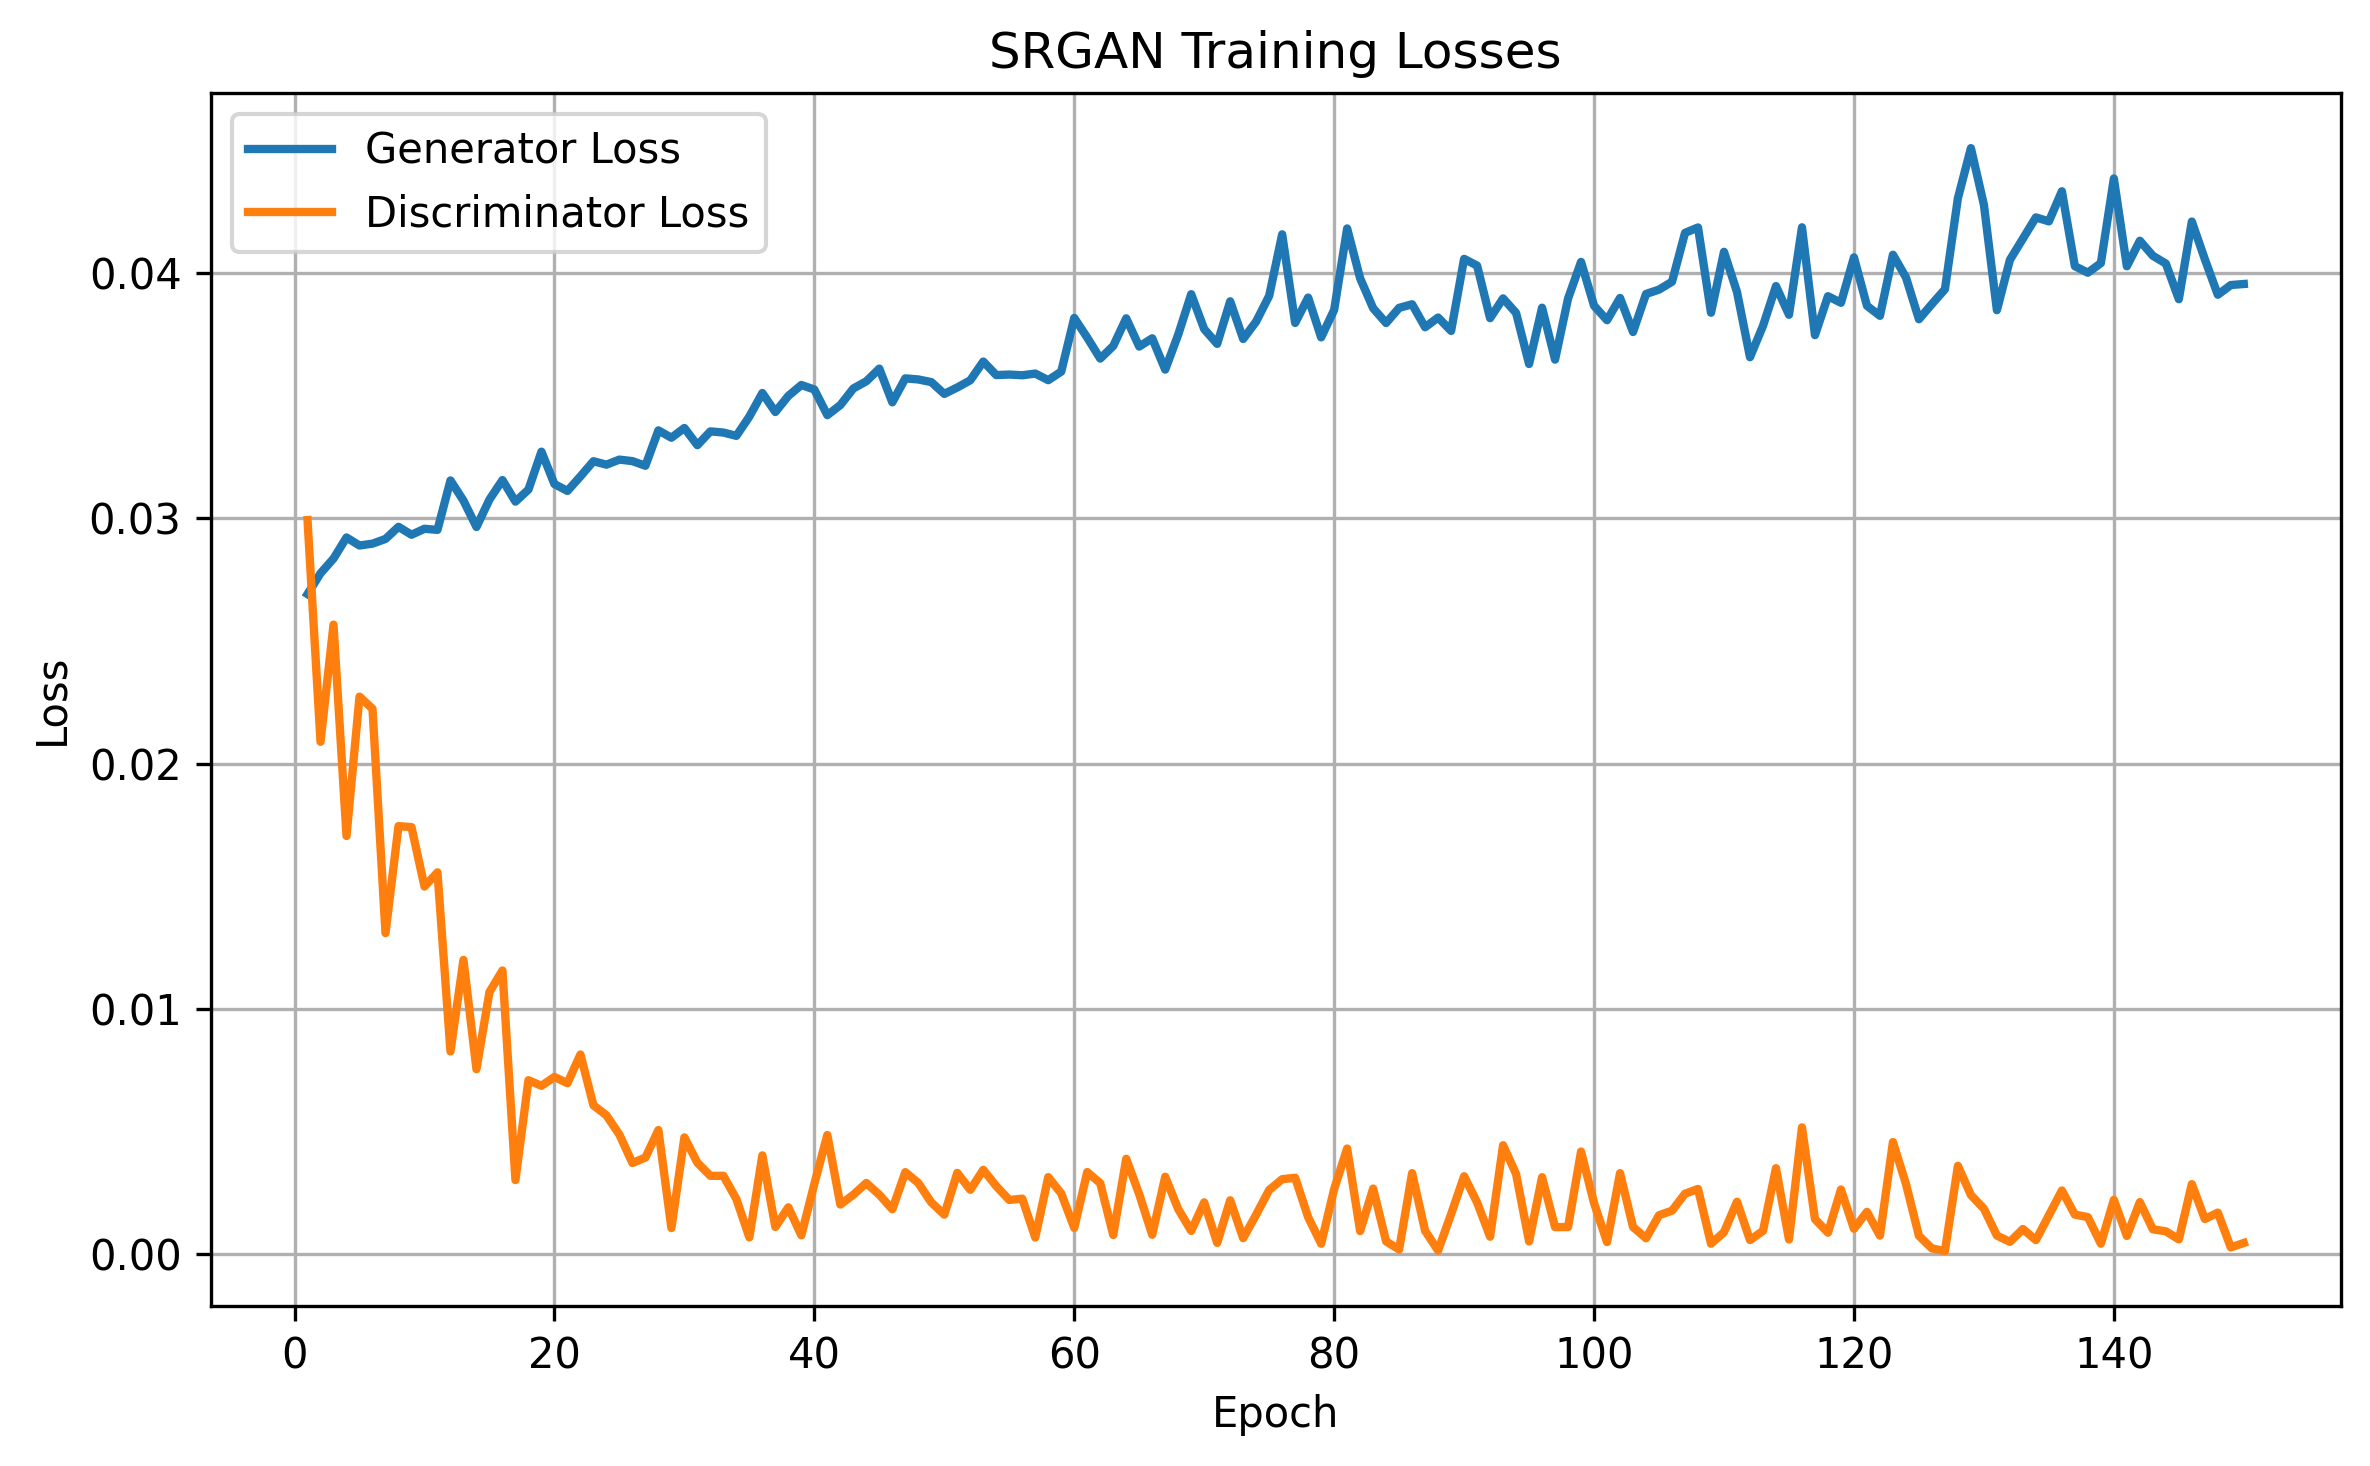

In [129]:
# Path to your SRGAN losses CSV
csv_path = os.path.join(model_dir, "modelSRGAN", "srgan_losses.csv")
df = pd.read_csv(csv_path)

# Plot losses
plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["g_loss"], label="Generator Loss", linewidth=2)
plt.plot(df["epoch"], df["d_loss"], label="Discriminator Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SRGAN Training Losses")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save correctly
plot_path = os.path.join(model_dir, "modelSRGAN", "srgan_loss_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.close()  # closes figure cleanly
print(f"Saved plot to: {plot_path}")
display(Image(filename=plot_path))

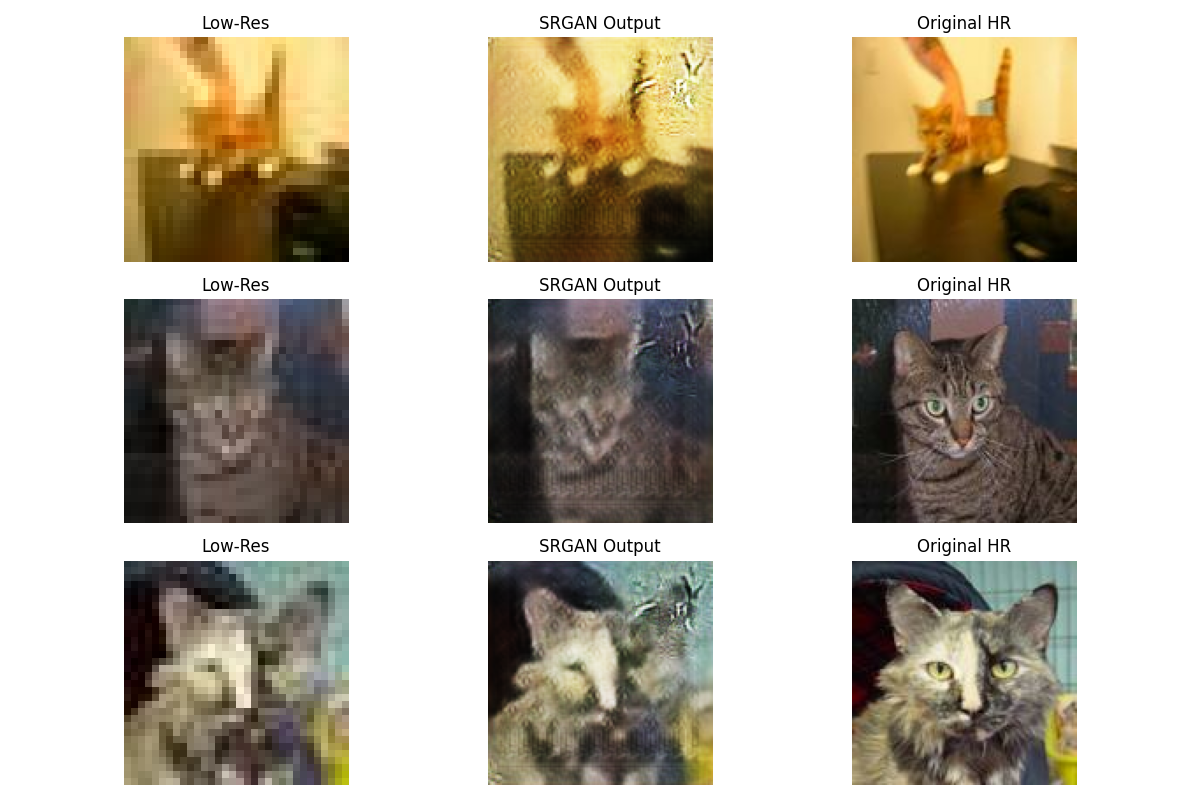

In [130]:
# Display srgan_epoch150
srgan_example = os.path.join(model_dir, "modelSRGAN", "srgan_epoch150.png")
display(Image(filename=srgan_example))

### Make the training data for Model B by using SRGAN

In [139]:
input_dir = os.path.join(data_dir, "train_32")
output_dir = os.path.join(data_dir, "train_128_from_32")
os.makedirs(output_dir, exist_ok=True)

# Collect image paths as plain Python strings
img_paths = sorted([
    os.path.join(input_dir, f) for f in os.listdir(input_dir)
    if f.lower().endswith(".jpg")
])

batch_size = 32

# Build dataset directly from Python string list
path_ds = tf.data.Dataset.from_tensor_slices(tf.constant(img_paths))

# Function to load and normalize each image
def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32) / 127.5 - 1.0
    return img, path

dataset = path_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Generate SRGAN images and save
for batch_imgs, batch_paths in tqdm(dataset, total=len(img_paths)//batch_size):
    sr_imgs = generator(batch_imgs, training=False)
    sr_imgs = ((sr_imgs + 1) / 2.0) * 255.0
    sr_imgs = tf.cast(sr_imgs, tf.uint8)

    # Save each image
    for img, path in zip(sr_imgs, batch_paths.numpy()):
        name = os.path.basename(path.decode("utf-8"))
        out_path = os.path.join(output_dir, name)
        tf.keras.utils.save_img(out_path, img)


100%|██████████| 525/525 [03:49<00:00,  2.29it/s]


### Binary Classifier (Model B) (Training Data gathered from previous step)

##### Define the dataframe

In [146]:
train_128_from_32_dir = os.path.join(data_dir, "train_128_from_32")
test_128_dir = os.path.join(data_dir, "test_128")

test128_df  = make_dataframe_numeric(test_128_dir)
train128_from_32_df = make_dataframe_numeric(train_128_from_32_dir)

print(train128_df.head())
print(f"Train images: {len(train128_df)} | Test images: {len(test128_df)}")

                                            filename  label
0  /content/drive/My Drive/gan2/data/train_128/ca...      0
1  /content/drive/My Drive/gan2/data/train_128/ca...      0
2  /content/drive/My Drive/gan2/data/train_128/ca...      0
3  /content/drive/My Drive/gan2/data/train_128/ca...      0
4  /content/drive/My Drive/gan2/data/train_128/ca...      0
Train images: 16800 | Test images: 7200


In [156]:
# No augmentations for Model B (SRGAN-generated images)

train_128_from_32_ds = tf.data.Dataset.from_tensor_slices(
    (train128_from_32_df["filename"], train128_from_32_df["label"])
)
train_128_from_32_ds = train_128_from_32_ds.map(
    lambda x, y: imageLoader(x, y, augment=False),
    num_parallel_calls=tf.data.AUTOTUNE
)
train_128_from_32_ds = train_128_from_32_ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

test_128_ds = tf.data.Dataset.from_tensor_slices(
    (test128_df["filename"], test128_df["label"])
)
test_128_ds = test_128_ds.map(
    lambda x, y: imageLoader(x, y, augment=False),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_128_ds = test_128_ds.batch(32).prefetch(tf.data.AUTOTUNE)


##### Define the model & train

In [158]:
# Define model
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights="imagenet")

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss="binary_crossentropy", metrics=["accuracy"])

# Used for Internal Tensorboard
csv_logger = CSVLogger("modelB.csv", append=False)

# Train model
history = model.fit(train_128_from_32_ds, validation_data=test_128_ds, epochs=40, callbacks=[csv_logger])

Epoch 1/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.6124 - loss: 0.7322 - val_accuracy: 0.4547 - val_loss: 0.9248
Epoch 2/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.4909 - loss: 0.9156 - val_accuracy: 0.4768 - val_loss: 0.9211
Epoch 3/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.4699 - loss: 0.9409 - val_accuracy: 0.4924 - val_loss: 0.9002
Epoch 4/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.4799 - loss: 0.9262 - val_accuracy: 0.5060 - val_loss: 0.8751
Epoch 5/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.4866 - loss: 0.9170 - val_accuracy: 0.5176 - val_loss: 0.8507
Epoch 6/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.4966 - loss: 0.8944 - val_accuracy: 0.5296 - val_loss: 0.8283
Epoch 7/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.5053 - loss: 0.8817 - val_accuracy: 0.5406 - val_loss: 0.8083
Epoch 8/40
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.5150 - loss: 0.8701 - 

In [159]:
modelB_dir = os.path.join(model_dir, "modelB")
os.makedirs(modelB_dir, exist_ok=True)
# Save model weights
model.save(os.path.join(modelB_dir, "modelB.keras"))

In [161]:
# Unfreeze top layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Step 3: Train again
csv_logger = CSVLogger("modelB_finetune.csv", append=False)

history = model.fit(
    train_128_from_32_ds,
    validation_data=test_128_ds,
    epochs=20,
    callbacks=[csv_logger],
    verbose=1
)


Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - accuracy: 0.8963 - loss: 0.2382 - val_accuracy: 0.7318 - val_loss: 0.7659
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8681 - loss: 0.5104 - val_accuracy: 0.5022 - val_loss: 4.8628
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.8804 - loss: 0.4541 - val_accuracy: 0.8112 - val_loss: 0.4234
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.8571 - loss: 0.5257 - val_accuracy: 0.7364 - val_loss: 0.5566
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.8774 - loss: 0.4688 - val_accuracy: 0.5028 - val_loss: 7.2261
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.8705 - loss: 0.4595 - val_accuracy: 0.8224 - val_loss: 0.3590
Epoch 7/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 29s 53ms/step - accuracy: 0.8839 - loss: 0.4176 - val_accuracy: 0.5004 - val_loss: 2.3092
Epoch 8/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.8758 - loss: 0.4815 - 

In [163]:
# Save model weights
model.save(os.path.join(modelB_dir, "modelB_finetune.keras"))

Saved plots:
/content/drive/My Drive/gan2/models/modelB/modelB_Acc_plot.png True
/content/drive/My Drive/gan2/models/modelB/modelB_Loss_plot.png True


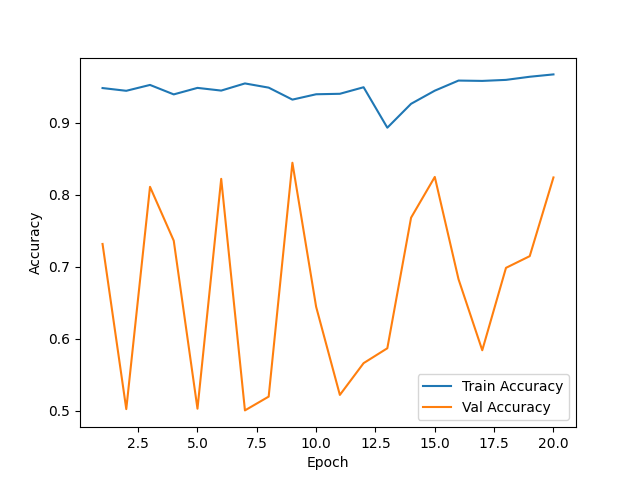

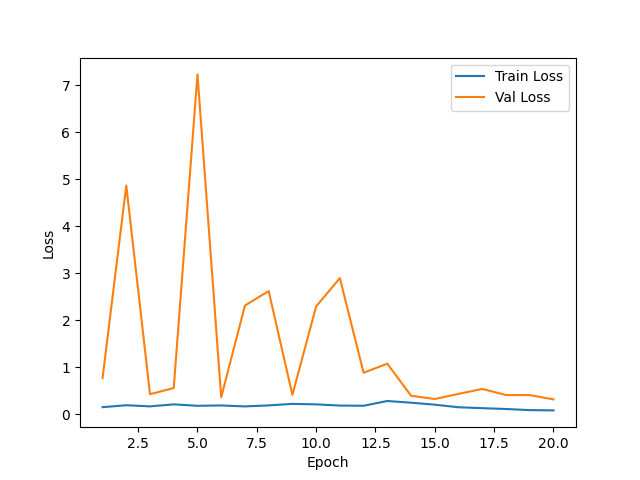

In [164]:
# Save CSV (add epoch column)
hist_df = pd.DataFrame(history.history)
hist_df["epoch"] = range(1, len(hist_df) + 1)
csv_path = os.path.join(modelB_dir, "modelB_finetune.csv")
hist_df.to_csv(csv_path, index=False)

# Read CSV
log_128 = pd.read_csv(csv_path)

# Accuracy plot
acc_path = os.path.join(modelB_dir, "modelB_Acc_plot.png")
plt.figure()
plt.plot(log_128["epoch"], log_128["accuracy"], label="Train Accuracy")
if "val_accuracy" in log_128.columns:
    plt.plot(log_128["epoch"], log_128["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(acc_path)
plt.close()

# Loss plot
loss_path = os.path.join(modelB_dir, "modelB_Loss_plot.png")
plt.figure()
plt.plot(log_128["epoch"], log_128["loss"], label="Train Loss")
if "val_loss" in log_128.columns:
    plt.plot(log_128["epoch"], log_128["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(loss_path)
plt.close()

# Verify the files exist
print("Saved plots:")
print(acc_path, os.path.exists(acc_path))
print(loss_path, os.path.exists(loss_path))

from IPython.display import Image, display
display(Image(filename=acc_path))
display(Image(filename=loss_path))


##### Determine Scores

In [167]:
# Collect predictions
y_true = []
y_pred = []

for imgs, labels in test_128_ds:
    preds = model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
fixed_thresh = 0.9983
print(f"Using fixed threshold: {fixed_thresh}")

# Apply threshold and compute metrics
y_class = (y_pred > fixed_thresh).astype(int)

acc = accuracy_score(y_true, y_class)
f1  = f1_score(y_true, y_class)
auc = roc_auc_score(y_true, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

Using fixed threshold: 0.9983
Accuracy: 0.6996
F1 Score: 0.5706
AUC: 0.9785
